In [1]:
import pandas as pd

**Exercise 1**

In [3]:
import pandas as pd
df_titanic = pd.read_csv('/content/train.csv')
row_before = df_titanic.shape[0]
num_dupl = df_titanic.duplicated().sum()
df_titanic.drop_duplicates(inplace=True)
row_after = df_titanic.shape[0]
print(f'The number of row before checking duplicates is {row_before} and after is {row_after}')

The number of row before checking duplicates is 891 and after is 891


**Exercise 2**

In [4]:
from sklearn.impute import SimpleImputer
print(df_titanic.isnull().sum())
#We delete the row of Embarked
df_titanic.dropna(subset=['Embarked'], inplace=True)

#We remplace with median
imputer = SimpleImputer(strategy='median')
df_titanic['Age'] = imputer.fit_transform(df_titanic[['Age']])

#We delete the column 'Cabin'
df_titanic.drop(columns=['Cabin'], inplace=True)
print(df_titanic.isnull().sum())
print(df_titanic.shape)




PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64
(889, 11)


**Exercise 3**

In [5]:
#Create a column 'Family size'
df_titanic['family_size'] = df_titanic['SibSp'] + df_titanic['Parch'] + 1
print(df_titanic['family_size'])
print(df_titanic.shape)

#Create a colum 'Title'
df_titanic['title'] = df_titanic['Name'].str.extract(r',\s*([^.]+)\.')

title_mapping = {
    'Mr': 'Mr',
    'Miss': 'Miss',
    'Mrs': 'Mrs',
    'Master': 'Master',
    # map rare/foreign titles
    'Dr': 'Rare',
    'Rev': 'Rare',
    'Col': 'Rare',
    'Mlle': 'Miss',
    'Major': 'Rare',
    'Ms': 'Mrs',
    'Mme': 'Mrs',
    'Don': 'Rare',
    'Lady': 'Rare',
    'Sir': 'Rare',
    'Capt': 'Rare',
    'the Countess': 'Rare',
    'Jonkheer': 'Rare'
}

df_titanic['title'] = df_titanic['title'].map(title_mapping)






0      2
1      2
2      1
3      2
4      1
      ..
886    1
887    1
888    4
889    1
890    1
Name: family_size, Length: 889, dtype: int64
(889, 12)


Exercise 4

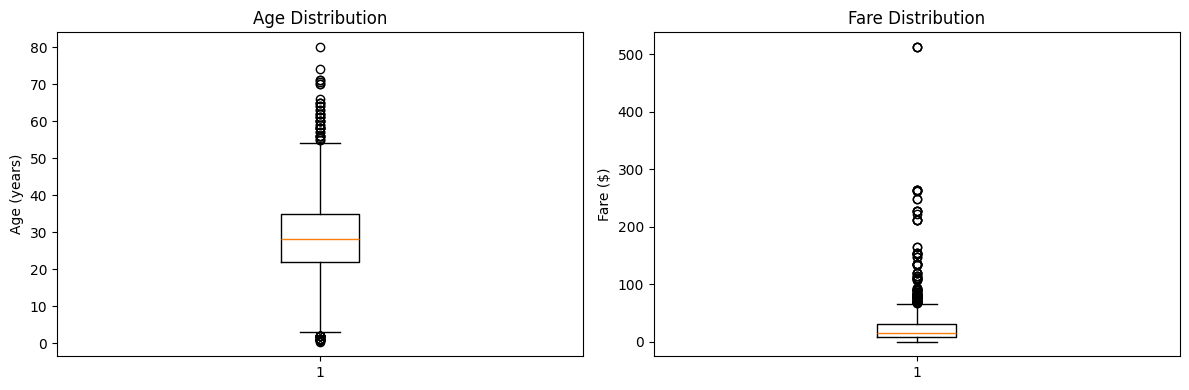


Boxplot interpretation:
  Box = middle 50% of data (Q1 to Q3)
  Line in box = median
  Whiskers = 1.5 × IQR from box
  Dots outside whiskers = OUTLIERS


In [6]:
# Visualize distributions with boxplots
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df_titanic['Age'].dropna())
axes[0].set_title('Age Distribution')
axes[0].set_ylabel('Age (years)')

axes[1].boxplot(df_titanic['Fare'].dropna())
axes[1].set_title('Fare Distribution')
axes[1].set_ylabel('Fare ($)')

plt.tight_layout()
plt.show()

print("\nBoxplot interpretation:")
print("  Box = middle 50% of data (Q1 to Q3)")
print("  Line in box = median")
print("  Whiskers = 1.5 × IQR from box")
print("  Dots outside whiskers = OUTLIERS")



In [7]:
# === CALCULATE IQR FOR FARE ===
Q1 = df_titanic['Fare'].quantile(0.25)
Q3 = df_titanic['Fare'].quantile(0.75)
IQR = Q3 - Q1
# Calculate upper/lower bounds
# Count outliers

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): ${Q1}")
print(f"Q3 (75th percentile): ${Q3}")
print(f"IQR: ${IQR}")

print(f"Lower bound: ${lower_bound}")
print(f"Upper bound: ${upper_bound}")

outliers = df_titanic[(df_titanic['Fare'] < lower_bound) | (df_titanic['Fare'] > upper_bound)]

print(f"Outliers detected: {len(outliers)/len(df_titanic) * 100:.1f}% of data")

Q1 (25th percentile): $7.8958
Q3 (75th percentile): $31.0
IQR: $23.1042
Lower bound: $-26.7605
Upper bound: $65.6563
Outliers detected: 12.8% of data


In [8]:
# === CALCULATE IQR FOR Age ===
Q1 = df_titanic['Age'].quantile(0.25)
Q3 = df_titanic['Age'].quantile(0.75)
IQR = Q3 - Q1
# Calculate upper/lower bounds
# Count outliers

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): {Q1} years")
print(f"Q3 (75th percentile): {Q3} years")
print(f"IQR: {IQR} years")

print(f"Lower age: {lower_bound} years")
print(f"Upper age: {upper_bound} years")

outliers = df_titanic[(df_titanic['Age'] < lower_bound) | (df_titanic['Age'] > upper_bound)]

print(f"Outliers detected: {len(outliers)/len(df_titanic) * 100:.1f}% of data")

Q1 (25th percentile): 22.0 years
Q3 (75th percentile): 35.0 years
IQR: 13.0 years
Lower age: 2.5 years
Upper age: 54.5 years
Outliers detected: 7.3% of data


In [9]:
# === CAP OUTLIERS AT 98TH PERCENTILE ===
fare_cap = df_titanic['Fare'].quantile(0.98)

outliers_count = (df_titanic['Fare'] > fare_cap).sum()

print(f"Capping fare at 98th percentile: ${fare_cap}")
print(f"Values to be capped: {outliers_count}")
print("Before capping")
print(f"Max fare: ${df_titanic['Fare'].max()}")


df_titanic['Fare'] = df_titanic['Fare'].clip(upper=fare_cap)
# Show before/after max values
print("After capping")
print(f"Max fare: ${df_titanic['Fare'].max()}")

Capping fare at 98th percentile: $211.3375
Values to be capped: 17
Before capping
Max fare: $512.3292
After capping
Max fare: $211.3375


In [10]:
# === CAP OUTLIERS AT 98TH PERCENTILE FOR AGE ===
fare_cap = df_titanic['Age'].quantile(0.98)

outliers_count = (df_titanic['Age'] > fare_cap).sum()

print(f"Capping fare at 98th percentile: {fare_cap} years")
print(f"Values to be capped: {outliers_count}")
print("Before capping")
print(f"Max fare: {df_titanic['Age'].max()} years")


df_titanic['Age'] = df_titanic['Age'].clip(upper=fare_cap)
# Show before/after max values
print("After capping")
print(f"Max fare: {df_titanic['Fare'].max()} years")

Capping fare at 98th percentile: 61.24000000000001 years
Values to be capped: 18
Before capping
Max fare: 80.0 years
After capping
Max fare: 211.3375 years


**Exercise 5**

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df_titanic['age_scaled'] = scaler.fit_transform(df_titanic[['Age']])
df_titanic['fare_scaled'] = scaler.fit_transform(df_titanic[['Fare']])

df_titanic[['age_scaled', 'fare_scaled']]

,age_scaled,fare_scaled
0,-0.569514,-0.585006
1,0.696629,1.021504
2,-0.252978,-0.568071
3,0.459227,0.565310
4,0.459227,-0.564935
...,...,...
886,-0.173844,-0.440746
887,-0.806916,-0.014238
888,-0.094711,-0.178569
889,-0.252978,-0.014238


In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()


df_titanic['Fare_minmax'] = scaler_minmax.fit_transform(df_titanic[['Fare']])

print(f"Minimum Fare : {df_titanic['Fare_minmax'].min()}") # 0.0
print(f"Maximum Fare : {df_titanic['Fare_minmax'].max()}") # 1.0

Minimum Fare : 0.0
Maximum Fare : 1.0


Exercise 6

In [15]:
#Convert categorical variables into numerical form using techniques like one-hot encoding or label encoding.
sex_mapping = {'male': 0, 'female': 1}
df_titanic['sex_encoded'] = df_titanic['Sex'].map(sex_mapping)

embarked_dummies = pd.get_dummies(df_titanic['Embarked'], prefix='Embarked').astype(int)
df_titanic = pd.concat([df_titanic, embarked_dummies], axis=1)

title_dummies = pd.get_dummies(df_titanic['title'], prefix='title').astype(int)
df_titanic = pd.concat([df_titanic, title_dummies], axis=1)

#delete the 'Ticket' column because it s a mix of letter and number
df_titanic.drop(columns=['Ticket'], inplace=True)
print(df_titanic)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

**Exercise 7**

In [16]:
bins = [0, 12, 18, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Middle Aged', 'Senior']
df_titanic['age_group'] = pd.cut(df_titanic['Age'], bins=bins, labels=labels)

# === LABEL ENCODE AGE_GROUP ===
age_mapping = {
    'Child': 0,
    'Teen': 1,
    'Young Adult': 2,
    'Middle Aged': 3,
    'Senior': 4
}

df_titanic['age_group_encoded'] = df_titanic['age_group'].map(age_mapping)
df_titanic['age_group_encoded']



,age_group_encoded
0,2
1,3
2,2
3,2
4,2
...,...
886,2
887,2
888,2
889,2
